# Import

In [24]:
import os
import glob
import cv2
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# Picture Acquisition

In [25]:
def create_cell_mask(img, morph_cleanup=True, kernel_size=5):
    """
    Segment cell area from non-cell padding using Otsu's thresholding.
    """
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    threshold, binary_mask = cv2.threshold(
        img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if morph_cleanup:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (kernel_size, kernel_size)
        )
        # close small holes inside cells
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        # remove small noise outside cells
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

    return binary_mask.astype(bool)


def load_image_and_remove_padding(
        image_path,
        min_valid_intensity=2,
        return_mask=False):
    """
    Load grayscale EL image and remove padding/bezel pixels.

    Parameters
    ----------
    image_path : str
        Path ke file .tiff
    min_valid_intensity : int
        Threshold untuk buang padding (default 2)
    return_mask : bool
        Kalau True, return juga mask 2D untuk visualisasi

    Returns
    -------
    phi_values : 1D numpy array
        Pixel intensity valid (tanpa padding)
    mask (optional) : 2D boolean array
    """

    # Load image grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Gagal load image: {image_path}")

    img = img.astype(np.float64)

    # Mask padding
    mask = img >= min_valid_intensity

    intensity_map = img[mask]

    if intensity_map.size == 0:
        raise ValueError("Tidak ada pixel valid setelah padding removal.")

    if return_mask:
        return intensity_map, mask
    else:
        return intensity_map


def trim_outliers(values, lower_percentile=0.1, upper_percentile=99.9):
    """
    Remove extreme outliers from a 1D array using percentile thresholds.

    Parameters
    ----------
    values : array-like
        Input data (misalnya intensity pixel).
    lower_percentile : float
        Persentil bawah yang dipertahankan.
    upper_percentile : float
        Persentil atas yang dipertahankan.

    Returns
    -------
    trimmed_values : numpy array
        Array tanpa outlier.
    """

    v = np.asarray(values, dtype=np.float64)

    # buang NaN
    v = v[np.isfinite(v)]

    if v.size == 0:
        return v

    lo = np.percentile(v, lower_percentile)
    hi = np.percentile(v, upper_percentile)

    trimmed = v[(v >= lo) & (v <= hi)]

    return trimmed

def make_valid_mask(phi: np.ndarray, morph_cleanup: bool = True, kernel_size: int = 5) -> np.ndarray:
    """
    Segment cell area from padding/bezel using Otsu's thresholding.
    """
    img_u8 = cv2.normalize(phi, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    mask = binary.astype(bool) & np.isfinite(phi)

    if morph_cleanup:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
        mask_u8 = mask.astype(np.uint8) * 255
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
        mask = mask_u8.astype(bool)

    return mask

# I0 by Rajput, 2018

In [26]:

def compute_f(intensity_map, I, Uth=0.0259, VT=0.0, N=60, pixel_area=1.0):
    """
    intensity_map di sini diasumsikan sudah berupa 1D cleaned values
    (padding removed, normalized, clipped).
    """
    #PERLU DIINGAT KARENA RUMUSNYA TADI UNTUK CELL
    
    phi_valid = np.asarray(intensity_map, dtype=np.float64)

    phi_valid = phi_valid[np.isfinite(phi_valid)]
    phi_valid = phi_valid[phi_valid > 0]

    if phi_valid.size == 0:
        raise ValueError("Tidak ada pixel valid untuk menghitung f.")

    integral_inv_phi = np.sum((1.0 / phi_valid))

    log_term = np.log( I * N / integral_inv_phi)
    sum_term = N * (Uth / 2.0) * log_term
    exponent = (sum_term - VT) / (N / 2.0 * Uth)

    return float(np.exp(exponent))


def compute_Vi_from_phi_values(intensity_map,
                               I,
                               f,
                               Uth=0.0259,
                               pixel_area=1.0):
    """
    Compute terminal voltage:
        Vi = (Uth/2) * ln( I / ( f * ∫(1/phi) d^2r ) )

    Parameters
    ----------
    phi_values : 1D numpy array
        Cleaned intensity values (padding removed already).
    I : float
        Injected current (Ampere).
    f : float
        Calibration factor.
    Uth : float
        Thermal voltage (kT/q or effective).
    pixel_area : float
        Area per pixel (set 1.0 if you only need relative scale).

    Returns
    -------
    Vi : float
        Terminal voltage (Volt).
    """

     #PERLU DIINGAT KARENA RUMUSNYA TADI UNTUK CELL


    phi = np.asarray(intensity_map, dtype=np.float64)

    if phi.size == 0:
        raise ValueError("phi_values kosong.")
    if np.any(phi <= 0):
        raise ValueError("phi_values mengandung nilai <= 0 (tidak boleh untuk 1/phi dan log).")
    if f <= 0 or I <= 0:
        raise ValueError("I dan f harus > 0.")

    integral_inv_phi = np.sum((1.0 / phi) * float(pixel_area))
    if integral_inv_phi <= 0:
        raise ValueError("Integral ∑(1/phi)*dA tidak valid.")

    arg = 60 * I / (f * integral_inv_phi)
    if arg <= 0:
        raise ValueError("Argumen log tidak valid (<=0).")

    Vi = (Uth / 2.0) * np.log(arg)
    return float(Vi)

"""
def compute_c_map(phi_image, Vi, Uth=0.0259, min_valid_intensity=2):
    
    Compute c(r) map in 2D.

    c(r) = Phi(r) * exp( -Vi / Uth )
    (Low bias assumption: U(r) ≈ Vi)

    Returns:
        c_map (2D numpy array)
        mask   (valid pixel mask)
    
    phi = phi_image.astype(np.float64)

    mask = phi >= min_valid_intensity

    c_map = np.full_like(phi, np.nan, dtype=np.float64)

    scale = np.exp(-float(Vi) / float(Uth))

    c_map[mask] = phi[mask] * scale

    return c_map, mask
"""

def compute_c_map(phi_image, Vi, Uth=0.0259):
    """
    Compute c(r) map in 2D.
    """
    phi = phi_image.astype(np.float64)

    mask = make_valid_mask(phi)

    c_map = np.full_like(phi, np.nan, dtype=np.float64)
    scale = np.exp(-float(Vi) / float(Uth))
    c_map[mask] = phi[mask] * scale

    return c_map, mask

def compute_J0_map(c_map, f):
    """
    Compute J0(r) map in 2D:

    J0(r) = f / c(r)

    Returns:
        J0_map (2D numpy array)
    """
    if f <= 0:
        raise ValueError("f harus > 0.")

    J0_map = np.full_like(c_map, np.nan, dtype=np.float64)

    valid = np.isfinite(c_map) & (c_map > 0)

    J0_map[valid] = float(f) / c_map[valid]

    return J0_map

# Rs by Rajput, 2018

In [27]:
import cv2
import numpy as np

def load_gray_cv2(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal load image: {path}")
    return img.astype(np.float64)

#def make_valid_mask(phi: np.ndarray, min_valid_intensity: int = 2) -> np.ndarray:
    # buang padding/bezel 0-1
 #   return (phi >= float(min_valid_intensity)) & np.isfinite(phi)



def compute_U_map(phi: np.ndarray, c_map: np.ndarray, Uth: float, mask: np.ndarray) -> np.ndarray:
    """
    U(r) = Uth * ln( Phi(r) / c(r) )
    """
    if phi.shape != c_map.shape:
        raise ValueError("phi dan c_map harus punya shape yang sama.")
    U = np.full_like(phi, np.nan, dtype=np.float64)

    safe = mask & np.isfinite(c_map) & (c_map > 0) & (phi > 0)
    U[safe] = Uth * np.log(phi[safe] / c_map[safe])
    return U

def estimate_Vi_from_brightest(
    phi: np.ndarray,
    U_map: np.ndarray,
    mask: np.ndarray,
    min_valid_pixels: int = 50
) -> float:
    """
    Estimasi Vi dari nilai maksimum U_map pada area valid.

    Asumsi:
    - Outlier/saturasi pada phi dan U_map sudah dibersihkan sebelum fungsi ini.
    - Vi dianggap sebagai tegangan internal maksimum pada area valid.
    """

    safe = mask & np.isfinite(U_map) & np.isfinite(phi)

    if np.count_nonzero(safe) < min_valid_pixels:
        raise ValueError("Terlalu sedikit pixel valid untuk estimasi Vi.")

    Vi = np.nanmax(U_map[safe])

    return float(Vi)

def compute_J_map(J0_map: np.ndarray, U_map: np.ndarray, Uth: float, mask: np.ndarray) -> np.ndarray:
    """
    J(r) = J0(r) * exp(U/Uth)
    """
    if J0_map.shape != U_map.shape:
        raise ValueError("J0_map dan U_map harus punya shape yang sama.")
    J = np.full_like(U_map, np.nan, dtype=np.float64)
    safe = mask & np.isfinite(J0_map) & (J0_map > 0) & np.isfinite(U_map)
    J[safe] = J0_map[safe] * np.exp(U_map[safe] / Uth)
    return J

def compute_Rs_map(Vi: float, U_map: np.ndarray, J_map: np.ndarray, mask: np.ndarray,
                   min_abs_J: float = 1e-30) -> np.ndarray:
    """
    Rs(r) = (Vi - U(r)) / J(r)
    min_abs_J mencegah division blow-up di area J sangat kecil.
    """
    Rs = np.full_like(U_map, np.nan, dtype=np.float64)
    safe = mask & np.isfinite(U_map) & np.isfinite(J_map) & (np.abs(J_map) > min_abs_J)
    Rs[safe] = (float(Vi) - U_map[safe]) / J_map[safe]
    return Rs/Rs[safe].size # normalisasi Rs dengan jumlah pixel valid untuk mendapatkan nilai rata-rata per pixel

def estimate_U_J_Rs_maps_from_highbias(
    phi_high_path: str,
    c_map: np.ndarray,
    J0_map: np.ndarray,
    Uth: float = 0.0259,
    min_valid_intensity: int = 2,
    exclude_top_percent: float = 0.1,
    band_width_percent: float = 0.4
):
    """
    High-bias pipeline:
    1) Load phi_high
    2) U_map = Uth ln(phi/c)
    3) Vi = median U pada brightest region (exclude top 0.1% phi)
    4) J_map = J0 exp(U/Uth)
    5) Rs_map = (Vi - U) / J
    """
    phi = load_gray_cv2(phi_high_path)
    mask = make_valid_mask(phi, min_valid_intensity=min_valid_intensity)

    U_map = compute_U_map(phi, c_map=c_map, Uth=Uth, mask=mask)
    Vi = estimate_Vi_from_brightest(phi, U_map=U_map, mask=mask,
                                    exclude_top_percent=exclude_top_percent,
                                    band_width_percent=band_width_percent)
    J_map = compute_J_map(J0_map=J0_map, U_map=U_map, Uth=Uth, mask=mask)
    Rs_map = compute_Rs_map(Vi=Vi, U_map=U_map, J_map=J_map, mask=mask)

    return {
        "phi_high": phi,
        "mask": mask,
        "Vi": Vi,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map
    }

# Uniting Program

## Rs Estimation Program Check

## Run lebih bener

In [28]:
import os
import glob
import numpy as np

def compute_f_from_cells(
    cell_folder,
    I,
    Uth=0.0259,
    VT=0.0,
    N=60
):
    """
    Eq. (15): f = exp[ ( Σ_{i=1}^{N} (Uth/2) * ln(I / ∫(1/Φ_i)d²r) - VT ) / (N/2 * Uth) ]
    
    Each cell folder contains individual cell images: _001, _002, ..., _0{N}
    """
    # find all cell images in folder, sorted
    patterns = [
        os.path.join(cell_folder, "*.tiff"),
        os.path.join(cell_folder, "*.tif"),
        os.path.join(cell_folder, "*.png"),
    ]
    cell_files = []
    for pat in patterns:
        cell_files.extend(glob.glob(pat))
    cell_files = sorted(cell_files)

    if len(cell_files) == 0:
        raise ValueError(f"No cell images found in {cell_folder}")

    N_found = len(cell_files)
    print(f"  Found {N_found} cell images in {os.path.basename(cell_folder)}")

    # per-cell log terms
    log_terms = []
    for cell_path in cell_files:
        phi = load_gray_cv2(cell_path)
        phi_valid = phi[np.isfinite(phi) & (phi > 0)].astype(np.float64)

        if phi_valid.size == 0:
            print(f"    WARNING: no valid pixels in {os.path.basename(cell_path)}, skipping")
            continue

        integral_inv_phi = np.sum(1.0 / phi_valid)
        log_term_i = (Uth / 2.0) * np.log(I / integral_inv_phi)
        log_terms.append(log_term_i)

    if len(log_terms) == 0:
        raise ValueError("No valid cells for f computation.")

    N_actual = len(log_terms)
    sum_term = np.sum(log_terms)
    exponent = (sum_term - VT) / (N_actual / 2.0 * Uth)
    f = float(np.exp(exponent))

    return f, N_actual


def find_cell_folder(base_dir, mod_name, bias="20"):
    """
    Find the cell folder for a module.
    e.g. mod_name = "3285_15_2_02182021" → looks for "3285_15_2_02182021_20"
    """
    folder_name = f"{mod_name}_{bias}"
    folder_path = os.path.join(base_dir, folder_name)
    if os.path.isdir(folder_path):
        return folder_path
    return None


def extract_mod_name_from_path(ell_path):
    """
    Extract module name from CSV path.
    e.g. './EL/3285_15_2_02182021_20.tiff' → '3285_15_2_02182021'
    """
    basename = os.path.basename(ell_path)              # 3285_15_2_02182021_20.tiff
    name = os.path.splitext(basename)[0]               # 3285_15_2_02182021_20
    name = name.replace("_wrp", "")                    # remove _wrp if present
    # remove last part (_20 or _80)
    parts = name.rsplit("_", 1)
    return parts[0]  # 3285_15_2_02182021

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt


def clip_for_display(img, mask, p_low=2, p_high=98):
    vals = img[mask & np.isfinite(img)]
    if vals.size == 0:
        return img
    lo, hi = np.percentile(vals, [p_low, p_high])
    return np.clip(img, lo, hi)






def segment_cells_grid(mask, n_rows=6, n_cols=10):
    """
    Simple grid-based cell segmentation from the valid mask bounding box.
    Returns list of 60 cell masks.
    """
    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cell_h = (y_max - y_min + 1) / n_rows
    cell_w = (x_max - x_min + 1) / n_cols

    cell_masks = []
    for r in range(n_rows):
        for c in range(n_cols):
            cell_mask = np.zeros_like(mask)
            r_start = int(y_min + r * cell_h)
            r_end   = int(y_min + (r + 1) * cell_h)
            c_start = int(x_min + c * cell_w)
            c_end   = int(x_min + (c + 1) * cell_w)
            cell_mask[r_start:r_end, c_start:c_end] = True
            cell_mask = cell_mask & mask  # intersect with valid mask
            cell_masks.append(cell_mask)
    return cell_masks


def compute_module_Rs(Rs_map, mask):
    """Harmonic mean of per-pixel Rs within a cell region."""
    safe = mask & np.isfinite(Rs_map) & (Rs_map > 0)
    rs_vals = Rs_map[safe]
    if rs_vals.size == 0:
        return np.nan
    return float(rs_vals.size / np.sum(1.0 / rs_vals))


def compute_module_J0(J0_map, mask):
    """Arithmetic mean of per-pixel J0 within a cell region."""
    safe = mask & np.isfinite(J0_map) & (J0_map > 0)
    j0_vals = J0_map[safe]
    if j0_vals.size == 0:
        return np.nan
    return float(np.mean(j0_vals))


def aggregate_module_parameters(Rs_map, J0_map, mask, n_rows=6, n_cols=10, Uth_cell=0.0259):
    """
    Full module aggregation from pixel maps:
    1. Segment into cells (grid)
    2. Per cell: harmonic mean Rs, arithmetic mean J0
    3. Module: sum Rs (series), geometric mean J0 (series)
    """
    cell_masks = segment_cells_grid(mask, n_rows=n_rows, n_cols=n_cols)
    N = n_rows * n_cols

    Rs_cells = []
    J0_cells = []

    print(f"\nPER-CELL PARAMETERS ({n_rows}x{n_cols} = {N} cells)")
    print("-" * 90)

    for i, cm in enumerate(cell_masks):
        rs_c = compute_module_Rs(Rs_map, cm)
        j0_c = compute_module_J0(J0_map, cm)
        Rs_cells.append(rs_c)
        J0_cells.append(j0_c)
        r, c = divmod(i, n_cols)
        print(f"  Cell [{r},{c}]  Rs = {rs_c:.4e}   J0 = {j0_c:.4e}")

    # filter out NaN cells
    Rs_arr = np.array(Rs_cells)
    J0_arr = np.array(J0_cells)
    valid = np.isfinite(Rs_arr) & np.isfinite(J0_arr) & (Rs_arr > 0) & (J0_arr > 0)

    Rs_module  = np.sum(Rs_arr[valid])                        # series: sum
    J0_module  = np.exp(np.mean(np.log(J0_arr[valid])))       # geometric mean
    Uth_module = N * Uth_cell

    print(f"\nMODULE SUMMARY ({int(valid.sum())}/{N} valid cells)")
    print("-" * 90)
    print(f"  Rs_module  (sum of cells)     : {Rs_module:.6e}")
    print(f"  J0_module  (geometric mean)   : {J0_module:.6e}")
    print(f"  Uth_module ({N} x {Uth_cell}) : {Uth_module:.4f} V")

    return {
        "N_cells": N,
        "n_valid_cells": int(valid.sum()),
        "Rs_cells": Rs_cells,
        "J0_cells": J0_cells,
        "Rs_module": float(Rs_module),
        "J0_module": float(J0_module),
        "Uth_module": float(Uth_module),
        "cell_masks": cell_masks,
    }
    


import os
import numpy as np
import matplotlib.pyplot as plt

def run_single_cell_analysis(
    low_cell_path,
    high_cell_path,
    low_resolution_path,
    I_low,
    Uth=0.0259,
    VT=0.0,
    N=1,
    min_valid_intensity=2,
    n_id=1.0,
    V_th=0.02585,
    n_rows=6,
    n_cols=10,
    display=True          # <-- new parameter
):
    # ----------------------------
    # LOW-BIAS
    # ----------------------------
    phi_low_values = load_image_and_remove_padding(
        low_cell_path #,
        #min_valid_intensity=min_valid_intensity
    )
    phi_low_values = trim_outliers(
        phi_low_values #,
        #lower_percentile=0.1,
        #upper_percentile=99.9
    )
     
    

    import os
import numpy as np
import matplotlib.pyplot as plt


def clip_for_display(img, mask, p_low=2, p_high=98):
    vals = img[mask & np.isfinite(img)]
    if vals.size == 0:
        return img
    lo, hi = np.percentile(vals, [p_low, p_high])
    return np.clip(img, lo, hi)


def summarize_map(name, arr, mask):
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        print(f"{name:12s}: tidak ada nilai valid")
        return {
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n": 0
        }
    elif name in ("J_map", "J0_map"):
        summary = {
            "mean": float(np.mean(vals))*vals.size/60, #the unit is in ampere and area of one pixel, divided by 60 to get the module est value
            "median": float(np.median(vals))*vals.size/60,
            "min": float(np.min(vals))*vals.size/60,
            "max": float(np.max(vals))*vals.size/60,
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )
    elif name == "Rs_map":
        summary = {
            "mean": float(np.mean(vals))*vals.size/60, # the first unit is ohm and area of one pixel, multiplied by 60 to get the module est value
            "median": float(np.median(vals))*vals.size/60,
            "min": float(np.min(vals))*vals.size/60,
            "max": float(np.max(vals))*vals.size/60,
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )
    else:
        summary = {
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
            "min": float(np.min(vals)),
            "max": float(np.max(vals)),
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )

    return summary



def segment_cells_grid(mask, n_rows=6, n_cols=10):
    """
    Simple grid-based cell segmentation from the valid mask bounding box.
    Returns list of 60 cell masks.
    """
    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cell_h = (y_max - y_min + 1) / n_rows
    cell_w = (x_max - x_min + 1) / n_cols

    cell_masks = []
    for r in range(n_rows):
        for c in range(n_cols):
            cell_mask = np.zeros_like(mask)
            r_start = int(y_min + r * cell_h)
            r_end   = int(y_min + (r + 1) * cell_h)
            c_start = int(x_min + c * cell_w)
            c_end   = int(x_min + (c + 1) * cell_w)
            cell_mask[r_start:r_end, c_start:c_end] = True
            cell_mask = cell_mask & mask  # intersect with valid mask
            cell_masks.append(cell_mask)
    return cell_masks


def compute_module_Rs(Rs_map, mask):
    """Harmonic mean of per-pixel Rs within a cell region."""
    safe = mask & np.isfinite(Rs_map) & (Rs_map > 0)
    rs_vals = Rs_map[safe]
    if rs_vals.size == 0:
        return np.nan
    return float(rs_vals.size / np.sum(1.0 / rs_vals))



def save_summaries_to_csv(summaries, low_cell_path, csv_path="sdm_modul2_hasil.csv"):
    # build one flat row: c_map_mean, c_map_median, ..., J0_map_min, etc.
    row = {"low_cell_path": low_cell_path}
    for map_name, stats in summaries.items():
        for stat_name, value in stats.items():   # mean, median, min, max, n
            row[f"{map_name}_{stat_name}"] = value

    write_header = not os.path.isfile(csv_path)
    pd.DataFrame([row]).to_csv(csv_path, mode="a", header=write_header, index=False)
    return row


def compute_module_J0(J0_map, mask):
    """Arithmetic mean of per-pixel J0 within a cell region."""
    safe = mask & np.isfinite(J0_map) & (J0_map > 0)
    j0_vals = J0_map[safe]
    if j0_vals.size == 0:
        return np.nan
    return float(np.mean(j0_vals))


def aggregate_module_parameters(Rs_map, J0_map, mask, n_rows=6, n_cols=10, Uth_cell=0.0259):
    """
    Full module aggregation from pixel maps:
    1. Segment into cells (grid)
    2. Per cell: harmonic mean Rs, arithmetic mean J0
    3. Module: sum Rs (series), geometric mean J0 (series)
    """
    cell_masks = segment_cells_grid(mask, n_rows=n_rows, n_cols=n_cols)
    N = n_rows * n_cols

    Rs_cells = []
    J0_cells = []

    print(f"\nPER-CELL PARAMETERS ({n_rows}x{n_cols} = {N} cells)")
    print("-" * 90)

    for i, cm in enumerate(cell_masks):
        rs_c = compute_module_Rs(Rs_map, cm)
        j0_c = compute_module_J0(J0_map, cm)
        Rs_cells.append(rs_c)
        J0_cells.append(j0_c)
        r, c = divmod(i, n_cols)
        print(f"  Cell [{r},{c}]  Rs = {rs_c:.4e}   J0 = {j0_c:.4e}")

    # filter out NaN cells
    Rs_arr = np.array(Rs_cells)
    J0_arr = np.array(J0_cells)
    valid = np.isfinite(Rs_arr) & np.isfinite(J0_arr) & (Rs_arr > 0) & (J0_arr > 0)

    Rs_module  = np.sum(Rs_arr[valid])                        # series: sum
    J0_module  = np.exp(np.mean(np.log(J0_arr[valid])))       # geometric mean
    Uth_module = N * Uth_cell

    print(f"\nMODULE SUMMARY ({int(valid.sum())}/{N} valid cells)")
    print("-" * 90)
    print(f"  Rs_module  (sum of cells)     : {Rs_module:.6e}")
    print(f"  J0_module  (geometric mean)   : {J0_module:.6e}")
    print(f"  Uth_module ({N} x {Uth_cell}) : {Uth_module:.4f} V")

    return {
        "N_cells": N,
        "n_valid_cells": int(valid.sum()),
        "Rs_cells": Rs_cells,
        "J0_cells": J0_cells,
        "Rs_module": float(Rs_module),
        "J0_module": float(J0_module),
        "Uth_module": float(Uth_module),
        "cell_masks": cell_masks,
    }
    


import os
import numpy as np
import matplotlib.pyplot as plt

def run_single_cell_analysis(
    low_cell_path,
    high_cell_path,
    I_low,
    Uth=0.0259,
    VT=0.0,
    N=1,
    min_valid_intensity=2,
    n_id=1.0,
    V_th=0.02585,
    n_rows=6,
    n_cols=10,
    display=True          # <-- new parameter
):
    # ----------------------------
    # LOW-BIAS
    # ----------------------------
    phi_low_values = load_image_and_remove_padding(
        low_cell_path #,
        #min_valid_intensity=min_valid_intensity
    )
    phi_low_values = trim_outliers(
        phi_low_values #,
        #lower_percentile=0.1,
        #upper_percentile=99.9
    )

    f = compute_f(phi_low_values, I=I_low, Uth=Uth, VT=VT, N=N)

    Vi_low = compute_Vi_from_phi_values(phi_low_values, I=I_low, f=f, Uth=Uth)


    phi_low_img = load_gray_cv2(low_cell_path) #ini yang pake load gray cv2
    c_map, mask_low = compute_c_map(
        phi_low_img,
        Vi=Vi_low,
        Uth=Uth,
        #min_valid_intensity=min_valid_intensity
    )
    J0_map = compute_J0_map(c_map, f=f)

    # ----------------------------
    # HIGH-BIAS
    # ----------------------------
    phi_high_img = load_gray_cv2(high_cell_path)
    mask_high = make_valid_mask(phi_high_img) #, min_valid_intensity=min_valid_intensity)
    mask = mask_low & mask_high

    U_map = compute_U_map(
        phi_high_img,
        c_map=c_map,
        Uth=Uth,
        mask=mask
    )

    Vi_high = estimate_Vi_from_brightest(
        phi_high_img,
        U_map=U_map,
        mask=mask
    )

    J_map = compute_J_map(
        J0_map=J0_map,
        U_map=U_map,
        Uth=Uth,
        mask=mask
    )

    Rs_map = compute_Rs_map(
        Vi=Vi_high,
        U_map=U_map,
        J_map=J_map,
        mask=mask
    )

    

    

    # ----------------------------
    # SUMMARY
    # ----------------------------
    print("=" * 90)
    print("SINGLE CELL ANALYSIS")
    print("-" * 90)
    print("Low cell file  :", os.path.basename(low_cell_path))
    print("High cell file :", os.path.basename(high_cell_path))
    print(f"I_low          : {I_low}")
    print(f"Uth            : {Uth}")
    print(f"VT             : {VT}")
    print(f"N              : {N}")
    print(f"n_id           : {n_id}")
    print(f"V_th           : {V_th}")
    print(f"f              : {f}")
    print(f"Vi_low         : {Vi_low}")
    print(f"Vi_high        : {Vi_high}")
    print("=" * 90)

    summaries = {}

    low_vals_valid = phi_low_img[mask & np.isfinite(phi_low_img)]
    high_vals_valid = phi_high_img[mask & np.isfinite(phi_high_img)]

    print("\nINTENSITY SUMMARY")
    print("-" * 90)

    if low_vals_valid.size > 0:
        print(
            f"{'Low intensity':12s}: "
            f"mean = {np.mean(low_vals_valid):.3e}, "
            f"median = {np.median(low_vals_valid):.3e}, "
            f"min = {np.min(low_vals_valid):.3e}, "
            f"max = {np.max(low_vals_valid):.3e}, "
            f"n = {low_vals_valid.size}"
        )
        summaries["low_intensity_mean"] = float(np.mean(low_vals_valid))
    else:
        print("Low intensity: tidak ada nilai valid")
        summaries["low_intensity_mean"] = np.nan

    if high_vals_valid.size > 0:
        print(
            f"{'High intensity':12s}: "
            f"mean = {np.mean(high_vals_valid):.3e}, "
            f"median = {np.median(high_vals_valid):.3e}, "
            f"min = {np.min(high_vals_valid):.3e}, "
            f"max = {np.max(high_vals_valid):.3e}, "
            f"n = {high_vals_valid.size}"
        )
        summaries["high_intensity_mean"] = float(np.mean(high_vals_valid))
    else:
        print("High intensity: tidak ada nilai valid")
        summaries["high_intensity_mean"] = np.nan

    print("\nMAP SUMMARY")
    print("-" * 90)
    summaries["c_map"] = summarize_map("c_map", c_map, mask)
    summaries["J0_map"] = summarize_map("J0_map", J0_map, mask)
    summaries["U_map"] = summarize_map("U_map", U_map, mask)
    summaries["J_map"] = summarize_map("J_map", J_map, mask)
    summaries["Rs_map"] = summarize_map("Rs_map", Rs_map, mask)

    # ----------------------------
    # DISPLAY IMAGES
    # ----------------------------
    if display:
        phi_low_disp = clip_for_display(phi_low_img, mask, 2, 98)
        phi_high_disp = clip_for_display(phi_high_img, mask, 2, 98)
        c_disp = clip_for_display(c_map, mask, 2, 98)
        J0_disp = clip_for_display(J0_map, mask, 2, 98)
        U_disp = clip_for_display(U_map, mask, 2, 98)
        J_disp = clip_for_display(J_map, mask, 2, 98)
        Rs_disp = clip_for_display(Rs_map, mask, 2, 98)

        mask_disp = np.where(mask, 1.0, 0.0)

        plt.figure(figsize=(20, 12))

        plt.subplot(3, 3, 1)
        plt.imshow(phi_low_disp, cmap="gray")
        plt.title("Low intensity (phi)")
        plt.colorbar()

        plt.subplot(3, 3, 2)
        plt.imshow(phi_high_disp, cmap="gray")
        plt.title("High intensity (phi)")
        plt.colorbar()

        plt.subplot(3, 3, 3)
        plt.imshow(mask_disp, cmap="gray")
        plt.title("Valid mask")
        plt.colorbar()

        plt.subplot(3, 3, 4)
        plt.imshow(c_disp, cmap="viridis")
        plt.title("c_map")
        plt.colorbar()

        plt.subplot(3, 3, 5)
        plt.imshow(J0_disp, cmap="plasma")
        plt.title("J0_map (Ampere/Pixel)")
        plt.colorbar()

        plt.subplot(3, 3, 6)
        plt.imshow(U_disp, cmap="magma")
        plt.title("U_map (Volt)")
        plt.colorbar()

        plt.subplot(3, 3, 7)
        plt.imshow(J_disp, cmap="inferno")
        plt.title("J_map (Ampere/pixel)")
        plt.colorbar()

        plt.subplot(3, 3, 8)
        plt.imshow(Rs_disp, cmap="cividis")
        plt.title("Rs_map (Ohm.pixel)")
        plt.colorbar()



        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))


    return {
        "f": f,
        "Vi_low": Vi_low,
        "Vi_high": Vi_high,
        "mask": mask,
        "phi_low_img": phi_low_img,
        "phi_high_img": phi_high_img,
        "c_map": c_map,
        "J0_map": J0_map,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map
    }



     # Extract the f value from the returned tuple



    Vi_low = compute_Vi_from_phi_values(phi_low_values, I=I_low, f=f, Uth=Uth)


    phi_low_img = load_gray_cv2(low_cell_path) #ini yang pake load gray cv2
    c_map, mask_low = compute_c_map(
        phi_low_img,
        Vi=Vi_low,
        Uth=Uth,
        #min_valid_intensity=min_valid_intensity
    )
    J0_map = compute_J0_map(c_map, f=f)

    # ----------------------------
    # HIGH-BIAS
    # ----------------------------
    phi_high_img = load_gray_cv2(high_cell_path)
    mask_high = make_valid_mask(phi_high_img) #, min_valid_intensity=min_valid_intensity)
    mask = mask_low & mask_high

    U_map = compute_U_map(
        phi_high_img,
        c_map=c_map,
        Uth=Uth,
        mask=mask
    )

    Vi_high = estimate_Vi_from_brightest(
        phi_high_img,
        U_map=U_map,
        mask=mask,
        exclude_top_percent=0.1,
        band_width_percent=0.4
    )

    J_map = compute_J_map(
        J0_map=J0_map,
        U_map=U_map,
        Uth=Uth,
        mask=mask
    )

    Rs_map = compute_Rs_map(
        Vi=Vi_high,
        U_map=U_map,
        J_map=J_map,
        mask=mask
    )

    

    

    # ----------------------------
    # SUMMARY
    # ----------------------------
    print("=" * 90)
    print("SINGLE CELL ANALYSIS")
    print("-" * 90)
    print("Low cell file  :", os.path.basename(low_cell_path))
    print("High cell file :", os.path.basename(high_cell_path))
    print(f"I_low          : {I_low}")
    print(f"Uth            : {Uth}")
    print(f"VT             : {VT}")
    print(f"N              : {N}")
    print(f"n_id           : {n_id}")
    print(f"V_th           : {V_th}")
    print(f"f              : {f}")
    print(f"Vi_low         : {Vi_low}")
    print(f"Vi_high        : {Vi_high}")
    print("=" * 90)

    summaries = {}

    low_vals_valid = phi_low_img[mask & np.isfinite(phi_low_img)]
    high_vals_valid = phi_high_img[mask & np.isfinite(phi_high_img)]

    print("\nINTENSITY SUMMARY")
    print("-" * 90)

    if low_vals_valid.size > 0:
        print(
            f"{'Low intensity':12s}: "
            f"mean = {np.mean(low_vals_valid):.3e}, "
            f"median = {np.median(low_vals_valid):.3e}, "
            f"min = {np.min(low_vals_valid):.3e}, "
            f"max = {np.max(low_vals_valid):.3e}, "
            f"n = {low_vals_valid.size}"
        )
        summaries["low_intensity_mean"] = float(np.mean(low_vals_valid))
    else:
        print("Low intensity: tidak ada nilai valid")
        summaries["low_intensity_mean"] = np.nan

    if high_vals_valid.size > 0:
        print(
            f"{'High intensity':12s}: "
            f"mean = {np.mean(high_vals_valid):.3e}, "
            f"median = {np.median(high_vals_valid):.3e}, "
            f"min = {np.min(high_vals_valid):.3e}, "
            f"max = {np.max(high_vals_valid):.3e}, "
            f"n = {high_vals_valid.size}"
        )
        summaries["high_intensity_mean"] = float(np.mean(high_vals_valid))
    else:
        print("High intensity: tidak ada nilai valid")
        summaries["high_intensity_mean"] = np.nan

    print("\nMAP SUMMARY")
    print("-" * 90)
    summaries["c_map"] = summarize_map("c_map", c_map, mask)
    summaries["J0_map"] = summarize_map("J0_map", J0_map, mask)
    summaries["U_map"] = summarize_map("U_map", U_map, mask)
    summaries["J_map"] = summarize_map("J_map", J_map, mask)
    summaries["Rs_map"] = summarize_map("Rs_map", Rs_map, mask)

    save_summaries_to_csv(summaries, low_cell_path)

    # ----------------------------
    # DISPLAY IMAGES
    # ----------------------------
    if display:
        phi_low_disp = clip_for_display(phi_low_img, mask, 2, 98)
        phi_high_disp = clip_for_display(phi_high_img, mask, 2, 98)
        c_disp = clip_for_display(c_map, mask, 2, 98)
        J0_disp = clip_for_display(J0_map, mask, 2, 98)
        U_disp = clip_for_display(U_map, mask, 2, 98)
        J_disp = clip_for_display(J_map, mask, 2, 98)
        Rs_disp = clip_for_display(Rs_map, mask, 2, 98)

        mask_disp = np.where(mask, 1.0, 0.0)

        plt.figure(figsize=(20, 12))

        plt.subplot(3, 3, 1)
        plt.imshow(phi_low_disp, cmap="gray")
        plt.title("Low intensity (phi)")
        plt.colorbar()

        plt.subplot(3, 3, 2)
        plt.imshow(phi_high_disp, cmap="gray")
        plt.title("High intensity (phi)")
        plt.colorbar()

        plt.subplot(3, 3, 3)
        plt.imshow(mask_disp, cmap="gray")
        plt.title("Valid mask")
        plt.colorbar()

        plt.subplot(3, 3, 4)
        plt.imshow(c_disp, cmap="viridis")
        plt.title("c_map")
        plt.colorbar()

        plt.subplot(3, 3, 5)
        plt.imshow(J0_disp, cmap="plasma")
        plt.title("J0_map (Ampere/Pixel)")
        plt.colorbar()

        plt.subplot(3, 3, 6)
        plt.imshow(U_disp, cmap="magma")
        plt.title("U_map (Volt)")
        plt.colorbar()

        plt.subplot(3, 3, 7)
        plt.imshow(J_disp, cmap="inferno")
        plt.title("J_map (Ampere/pixel)")
        plt.colorbar()

        plt.subplot(3, 3, 8)
        plt.imshow(Rs_disp, cmap="cividis")
        plt.title("Rs_map (Ohm.pixel)")
        plt.colorbar()



        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))


    return {
        "f": f,
        "Vi_low": Vi_low,
        "Vi_high": Vi_high,
        "mask": mask,
        "phi_low_img": phi_low_img,
        "phi_high_img": phi_high_img,
        "c_map": c_map,
        "J0_map": J0_map,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map
    }



# Run Final

SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3249_25_3_02082021_20_wrp.tiff
High cell file : 3249_25_3_02082021_80_wrp.tiff
I_low          : 1.875
Uth            : 0.0259
VT             : 36.923
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 1.3067995643856045e-24
Vi_low         : 0.6153833333333333
Vi_high        : 0.6529966686521459

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 1.421e+02, median = 1.430e+02, min = 7.000e+00, max = 2.310e+02, n = 15254562
High intensity: mean = 1.731e+02, median = 1.720e+02, min = 1.600e+01, max = 2.550e+02, n = 15254562

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 6.821e-09, median = 6.863e-09, min = 3.359e-10, max = 1.109e-08, n = 15254562
J0_map      : mean = 5.075e-1

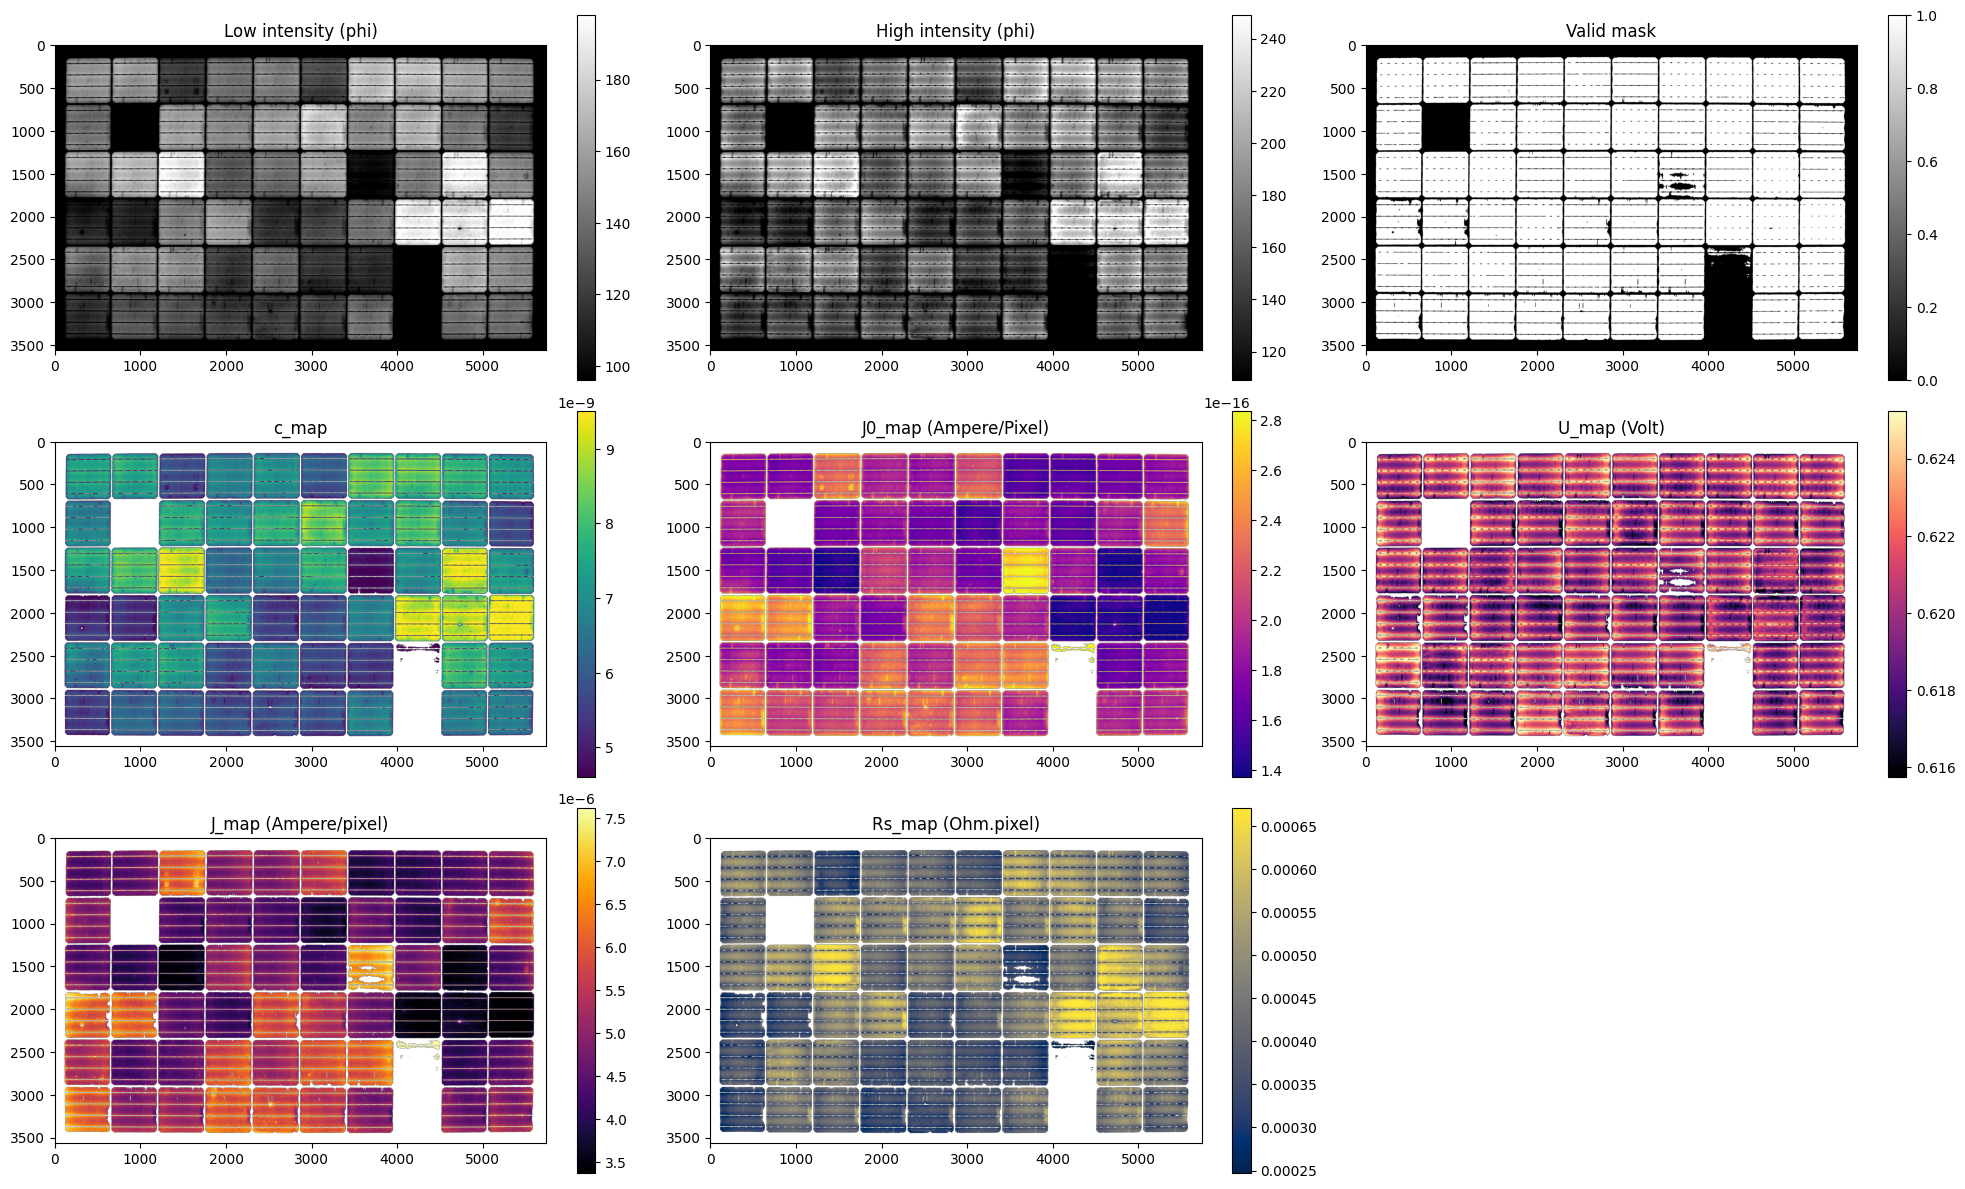

<Figure size 1000x400 with 0 Axes>

In [30]:
# =========================================================
# CONTOH PAKAI
# =========================================================
low_cell_path  = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL\3249_25_3_02082021_20_wrp.tiff"
high_cell_path = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL\3249_25_3_02082021_80_wrp.tiff"

I_low = 1.875 
Uth = 0.0259
VT = 36.923
N = 60   # coba mulai dari 1 kalau memang image-nya satu cell

out = run_single_cell_analysis(
    low_cell_path=low_cell_path,
    high_cell_path=high_cell_path,
    #low_resolution_path  = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_cell_low_res\3249_25_3_02082021_20", #folder yang berisi 60 cell images untuk low bias
    I_low=I_low,
    Uth=Uth,
    VT=VT,
    N=N,
    min_valid_intensity= 1e-6,
    display=True
)

## Mencari F

In [15]:
import pandas as pd
import numpy as np
import traceback
import time
import os

def run_batch_module_analysis(
    csv_path,
    output_csv="module_Rs_J0_results.csv",
    n_rows=6,
    n_cols=10,
    Uth=0.0259,
    N=1,
    n_id=1.0,
    V_th=0.02585
):
    df = pd.read_csv(csv_path)
    
    df = df.dropna(subset=["ELLPath", "ELHPath"]).reset_index(drop=True)
    results = []
    t0 = time.time()
    base_dir = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding"

    for idx, row in df.iterrows():
        low_path  = os.path.normpath(os.path.join(base_dir, row["ELLPath"]))
        high_path = os.path.normpath(os.path.join(base_dir, row["ELHPath"]))

        # fix: actual files have _wrp before .tiff
        if not os.path.isfile(low_path):
            low_path = low_path.replace(".tiff", "_wrp.tiff")
        if not os.path.isfile(high_path):
            high_path = high_path.replace(".tiff", "_wrp.tiff")
            
        I_low     = row["Low_Applied_Current_(A)"]
        VT        = row["Low_Applied_Voltage_(V)"]
        mod_id    = row.get("Mod_ID", idx)

        print(f"\n[{idx+1}/{len(df)}] Mod_ID={mod_id} | I_low={I_low} | VT={VT} | {low_path}")


        try:
            out = run_single_cell_analysis(
                low_cell_path=low_path,
                high_cell_path=high_path,
                #low_resolution_path=find_cell_folder(base_dir, extract_mod_name_from_path(low_path), bias="20"),
                I_low=I_low,
                Uth=Uth,
                VT=VT,
                N=N,
                n_id=n_id,
                V_th=V_th,
                n_rows=n_rows,
                n_cols=n_cols,
                display=False
            )

            mod = out["summaries"]["module"]

            results.append({
                "Mod_ID": mod_id,
                "ELLPath": low_path,
                "ELHPath": high_path,
                "I_low": I_low,
                "VT": VT,
                "Vi_low": out["Vi_low"],
                "Vi_high": out["Vi_high"],
                "f": out["f"],
                "Rs_module": mod["Rs_module"],
                "J0_module": mod["J0_module"],
                "Uth_module": mod["Uth_module"],
                "N_cells": mod["N_cells"],
                "n_valid_cells": mod["n_valid_cells"],
                "status": "ok"
            })

        except Exception as e:
            print(f"  ERROR: {e}")
            traceback.print_exc()
            results.append({
                "Mod_ID": mod_id,
                "ELLPath": low_path,
                "ELHPath": high_path,
                "I_low": I_low,
                "VT": VT,
                "Vi_low": np.nan,
                "Vi_high": np.nan,
                "f": np.nan,
                "Rs_module": np.nan,
                "J0_module": np.nan,
                "Uth_module": np.nan,
                "N_cells": np.nan,
                "n_valid_cells": np.nan,
                "status": str(e)
            })

        # save checkpoint every 50 modules
        if (idx + 1) % 50 == 0:
            pd.DataFrame(results).to_csv(output_csv, index=False)
            elapsed = time.time() - t0
            print(f"  Checkpoint saved ({idx+1}/{len(df)}, {elapsed:.0f}s elapsed)")

    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, index=False)

    ok = (results_df["status"] == "ok").sum()
    fail = len(results_df) - ok
    elapsed = time.time() - t0
    print(f"\nDone! {len(results_df)} modules in {elapsed:.0f}s → {output_csv}")
    print(f"  OK: {ok}, Failed: {fail}")

    return results_df

In [16]:
results_df = run_batch_module_analysis(
    csv_path="AnonDB_zub_60.csv",
    output_csv="module_Rs_J0_results.csv",
    N=60
)


[1/424] Mod_ID=3395 | I_low=1.7 | VT=40.228 | C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL\3395_30_1_03182016_20_wrp.tiff
SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3395_30_1_03182016_20_wrp.tiff
High cell file : 3395_30_1_03182016_80_wrp.tiff
I_low          : 1.7
Uth            : 0.0259
VT             : 40.228
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 4.359924183752933e-27
Vi_low         : 0.6704666666666667
Vi_high        : 0.6945509830104519

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 1.315e+02, median = 1.300e+02, min = 5.800e+01, max = 2.350e+02, n = 48002281
High intensity: mean = 1.604e+02, median = 1.600e+02, min = 6.300e+01, max = 2.550e+02, n = 48002281

MAP SUMMARY
-------------------------------------------------------

Traceback (most recent call last):
  File "C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_47192\3395585081.py", line 57, in run_batch_module_analysis
    mod = out["summaries"]["module"]
KeyError: 'summaries'


SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3394_30_1_03182016_20_wrp.tiff
High cell file : 3394_30_1_03182016_80_wrp.tiff
I_low          : 1.7
Uth            : 0.0259
VT             : 39.965
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 5.918738464826514e-27
Vi_low         : 0.6660833333333334
Vi_high        : 0.6903157619550778

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 1.261e+02, median = 1.250e+02, min = 5.400e+01, max = 2.460e+02, n = 48342304
High intensity: mean = 1.572e+02, median = 1.570e+02, min = 6.500e+01, max = 2.550e+02, n = 48342304

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 8.544e-10, median = 8.471e-10, min = 3.660e-10, max = 1.667e-09, n = 48342304
J0_map      : mean = 5.888e-12, 

Traceback (most recent call last):
  File "C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_47192\3395585081.py", line 57, in run_batch_module_analysis
    mod = out["summaries"]["module"]
KeyError: 'summaries'


SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3411_30_1_03182016_20_wrp.tiff
High cell file : 3411_30_1_03182016_80_wrp.tiff
I_low          : 1.7
Uth            : 0.0259
VT             : 40.115
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 4.9899665594701614e-27
Vi_low         : 0.6685833333333334
Vi_high        : 0.6875931349679106

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 1.306e+02, median = 1.250e+02, min = 5.300e+01, max = 2.550e+02, n = 48448478
High intensity: mean = 1.395e+02, median = 1.340e+02, min = 5.300e+01, max = 2.550e+02, n = 48448478

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 8.037e-10, median = 7.692e-10, min = 3.261e-10, max = 1.569e-09, n = 48448478
J0_map      : mean = 5.267e-12,

...

Traceback (most recent call last):
  File "C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_47192\3395585081.py", line 57, in run_batch_module_analysis
    mod = out["summaries"]["module"]
KeyError: 'summaries'


SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3549_15_1_01142020_20_wrp.tiff
High cell file : 3549_15_1_01142020_80_wrp.tiff
I_low          : 1.605
Uth            : 0.0259
VT             : 33.66
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 2.1499195782605158e-23
Vi_low         : 0.5609999999999998
Vi_high        : 0.6558862466347577

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 6.586e+01, median = 6.200e+01, min = 0.000e+00, max = 1.880e+02, n = 8183199
High intensity: mean = 1.257e+02, median = 1.210e+02, min = 1.000e+01, max = 2.550e+02, n = 8183199

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 2.581e-08, median = 2.429e-08, min = 0.000e+00, max = 7.366e-08, n = 8183199
J0_map      : mean = 1.224e-10, m

Traceback (most recent call last):
  File "C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_47192\3395585081.py", line 57, in run_batch_module_analysis
    mod = out["summaries"]["module"]
KeyError: 'summaries'


SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3547_15_1_01142020_20_wrp.tiff
High cell file : 3547_15_1_01142020_80_wrp.tiff
I_low          : 1.605
Uth            : 0.0259
VT             : 33.623
N              : 60
n_id           : 1.0
V_th           : 0.02585
f              : 1.9114892256572436e-23
Vi_low         : 0.5603833333333333
Vi_high        : 0.6606474395158477

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 7.455e+01, median = 7.400e+01, min = 0.000e+00, max = 1.890e+02, n = 7357546
High intensity: mean = 1.365e+02, median = 1.320e+02, min = 8.000e+00, max = 2.550e+02, n = 7357546

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 2.991e-08, median = 2.969e-08, min = 0.000e+00, max = 7.584e-08, n = 7357546
J0_map      : mean = 8.483e-11, 

Traceback (most recent call last):
  File "C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_47192\3395585081.py", line 57, in run_batch_module_analysis
    mod = out["summaries"]["module"]
KeyError: 'summaries'
